# LLM Sentiment Analysis Benchmark Pipeline
This notebook serves as a complete pipeline to benchmark various Large Language Models (LLMs) on a Persian Sentiment Analysis task.

**Workflow Overview:**
1. **Setup & Configurations:** Import libraries and define global constants.
2. **Dataset Preparation:** Filter the ground-truth dataset to a specific subset (e.g., 200 rows).
3. **Automated API Execution:** Send batched requests to Azure AI models and save results.
4. **Missing Data Audit:** Check for rows that failed due to API timeouts, rate limits, or JSON formatting errors.
5. **Interactive Manual Runner:** A fallback tool to manually query models (via copy-pasting prompts) to fill in missing gaps or test new models.
6. **Evaluation & Metrics:** Calculate Accuracy, Precision, Recall, and F1-Score to generate a final leaderboard.

# Install dependencies
All the following packages are needed in order to to make this jupyter fully functional.

```bash
pip install -r requirements.txt
```

In [4]:
import os
import re
import csv
import json
import time
import glob
import random
import pandas as pd
import concurrent.futures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    import pyperclip
    HAS_CLIP = True
except ImportError:
    HAS_CLIP = False

# Global Configurations
MAIN_CSV = "data/downsample_balanced_binary_label_50.csv"
RESULTS_DIR = "./Sentiment_Results"
MAX_ROWS = 200
BATCH_SIZE = 200

# Ensure the main results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)
print("✅ Libraries imported and global configurations set.")

✅ Libraries imported and global configurations set.


## Step 1: Automated LLM Inference (Azure API)
This section automatically connects to the Azure AI Inference endpoints to fetch sentiment predictions. Since APIs can face rate limits and timeouts, we use multithreading and automatic key rotation.

**What this code does:**
- Divides the dataset into manageable batches.
- Checks if a batch is already processed (to prevent redundant API calls).
- Sends prompts to the selected models asking for a strictly formatted JSON array.
- Retries failed requests up to a maximum limit and logs persistently failed batches into a root log file.
- Saves valid responses inside model-specific subdirectories (e.g., `./Sentiment_Results/Ministral-3B/`).

In [5]:
from azure.ai.inference import ChatCompletionsClient
from azure.core.credentials import AzureKeyCredential

MAX_RETRIES = 3
REQUEST_TIMEOUT = 45
ERROR_LOG_FILE = os.path.join(RESULTS_DIR, f"failed_batches_log_batch_{BATCH_SIZE}.csv")

API_KEYS = [
    "...",
    "...",
]

MODELS_TO_RUN = [
    {"name": "gpt-4.1", "rpm": 10},
]

global_executor = concurrent.futures.ThreadPoolExecutor(max_workers=10)

class AzureText:
    def __init__(self, model_name, rpm):
        self.model = model_name
        self.rpm = rpm
        self.keys = API_KEYS
        self.current_key_idx = 0
        self.setup_client()

    def setup_client(self):
        if self.keys[self.current_key_idx]:
            self.client = ChatCompletionsClient(
                endpoint="https://models.inference.ai.azure.com",
                credential=AzureKeyCredential(self.keys[self.current_key_idx]),
            )

    def rotate_key(self):
        self.current_key_idx = (self.current_key_idx + 1) % len(self.keys)
        print(f"\n[SWITCH] Key rotated. Index: {self.current_key_idx}")
        self.setup_client()

    def _make_api_call(self, prompt):
        return self.client.complete(
            messages=[{"role": "user", "content": prompt}],
            model=self.model,
            temperature=0.0,
        )

    def generate_text(self, prompt):
        try:
            future = global_executor.submit(self._make_api_call, prompt)
            response = future.result(timeout=REQUEST_TIMEOUT)
            return {"message": response.choices[0].message.content, "has_error": False, "is_rate_limit": False}
        except concurrent.futures.TimeoutError:
            return {"message": f"Timeout! No response in {REQUEST_TIMEOUT}s.", "has_error": True, "is_rate_limit": False}
        except Exception as e:
            error_msg = str(e).lower()
            is_rate_limit = "429" in error_msg or "rate limit" in error_msg or "quota" in error_msg
            return {"message": str(e), "has_error": True, "is_rate_limit": is_rate_limit}

def extract_json(text):
    try:
        match = re.search(r'```(?:json)?(.*?)```', text, re.DOTALL)
        if match:
            return json.loads(match.group(1).strip())
        start_idx = text.find('[')
        end_idx = text.rfind(']')
        if start_idx != -1 and end_idx != -1:
            return json.loads(text[start_idx:end_idx+1])
        return json.loads(text.strip())
    except Exception:
        return None

def get_processed_ids(filename):
    if not os.path.exists(filename):
        return set()
    with open(filename, mode='r', encoding='utf-8') as f:
        return set(row['id'] for row in csv.DictReader(f))

def save_results(filename, results_list):
    file_exists = os.path.exists(filename)
    with open(filename, mode='a', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['id', 'sentiment', 'raw_text'])
        if not file_exists:
            writer.writeheader()
        writer.writerows(results_list)

def log_failed_batch(model_name, batch_ids, reason):
    file_exists = os.path.exists(ERROR_LOG_FILE)
    with open(ERROR_LOG_FILE, mode='a', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Model', 'Batch_Size', 'First_ID', 'Last_ID', 'Reason'])
        writer.writerow([time.strftime("%Y-%m-%d %H:%M:%S"), model_name, len(batch_ids), batch_ids[0], batch_ids[-1], reason])

# Load data into dictionary
dataset = []
df = pd.read_csv(MAIN_CSV)
for idx, row in df.iterrows():
    if pd.notna(row.get('Text')):
        dataset.append({"id": f"row_{idx}", "text": str(row['Text'])})

# Execution
if API_KEYS[0]: # Run only if API keys are set
    clients = {m["name"]: AzureText(m["name"], m["rpm"]) for m in MODELS_TO_RUN}
    for i in range(0, len(dataset), BATCH_SIZE):
        batch_data = dataset[i : i + BATCH_SIZE]
        batch_ids = [item['id'] for item in batch_data]

        print(f"\n{'='*50}\nBATCH: {batch_ids[0]} to {batch_ids[-1]}\n{'='*50}")

        for m in MODELS_TO_RUN:
            model_name = m["name"]
            llm = clients[model_name]

            model_dir = os.path.join(RESULTS_DIR, model_name)
            os.makedirs(model_dir, exist_ok=True)
            output_csv = os.path.join(model_dir, f"{model_name}-batch-{BATCH_SIZE}.csv")

            processed_ids = get_processed_ids(output_csv)
            unprocessed_batch = [item for item in batch_data if item['id'] not in processed_ids]

            if not unprocessed_batch:
                print(f"SKIP: {model_name}")
                continue

            print(f"-> Processing {model_name} ({len(unprocessed_batch)} items)")
            reviews_text = "\n".join([f"ID: {item['id']} | Text: {item['text']}" for item in unprocessed_batch])
            prompt = f"You are an expert sentiment analyzer. Read the following Persian texts and classify the sentiment of each as either 1 (Positive) or 0 (Negative).\nYou MUST output ONLY a valid JSON array. Do not include any other text or explanation.\nThe JSON format must strictly match this structure:\n[\n  {{\"id\": \"row_id\", \"sentiment\": 1 or 0}}\n]\n\nTexts:\n{reviews_text}"

            success = False
            fail_reason = "Failed after max retries"

            for attempt in range(MAX_RETRIES):
                result = llm.generate_text(prompt)
                if result["has_error"]:
                    print(f"   Error {attempt+1}: {result['message']}")
                    if result.get("is_rate_limit"):
                        llm.rotate_key()
                    time.sleep(5)
                    continue

                parsed_json = extract_json(result["message"])
                if parsed_json is None:
                    print(f"   JSON Parse Error")
                    fail_reason = "JSON Error"
                    break

                if len(parsed_json) != len(unprocessed_batch):
                    reason = f"Mismatch: Expected {len(unprocessed_batch)}, Got {len(parsed_json)}"
                    print(f"   {reason} (Attempt {attempt+1})")
                    time.sleep(5)
                    continue

                to_save = []
                for item in parsed_json:
                    orig_text = next((d['text'] for d in unprocessed_batch if str(d['id']) == str(item.get('id'))), "")
                    to_save.append({'id': item.get('id'), 'sentiment': item.get('sentiment'), 'raw_text': orig_text})

                save_results(output_csv, to_save)
                print(f"   Saved {len(to_save)} items to {output_csv}")
                success = True
                time.sleep(60.0 / llm.rpm)
                break

            if not success:
                log_failed_batch(model_name, batch_ids, fail_reason)
    print("\n✅ Automated inference completed!")
else:
    print("⚠️ API keys not provided. Skipping automated inference step.")


BATCH: row_0 to row_199
-> Processing gpt-4.1 (200 items)


KeyboardInterrupt: 

## Step 2: Missing Data Detection
LLM endpoints are unpredictable. Sometimes they hallucinate responses, return invalid JSONs, or time out.

**What this code does:**
- It scans all model subdirectories inside `Sentiment_Results`.
- It calculates the difference between the expected target IDs (`row_0` to `row_199`) and the actual processed IDs.
- Outputs a report identifying exactly which models failed on which specific rows.

In [17]:
all_expected_ids = set([f"row_{i}" for i in range(MAX_ROWS)])

# Find all CSV files inside model subdirectories
csv_files = glob.glob(os.path.join(RESULTS_DIR, "*", "*.csv"))

if not csv_files:
    print(f"❌ No output files found in {RESULTS_DIR} subdirectories!")
else:
    print(f"✅ Found {len(csv_files)} output files. Auditing for missing rows...\n")
    missing_report = {}

    for file in csv_files:
        model_name = os.path.basename(file).replace(".csv", "")
        df = pd.read_csv(file)

        if 'id' in df.columns:
            processed_ids = set(df['id'].astype(str).tolist())
            missing_ids = all_expected_ids - processed_ids

            if missing_ids:
                # Sort numerically for better readability
                missing_report[model_name] = sorted(list(missing_ids), key=lambda x: int(x.split('_')[1]))
                print(f"⚠️ Model '{model_name}': Missing {len(missing_ids)} rows.")
            else:
                print(f"✅ Model '{model_name}': 100% Complete.")

    # Generate persistent report file
    report_path = "missing_ids_report.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        if not missing_report:
            f.write("Congratulations! All models have processed 100% of the dataset.\n")
        else:
            for model, m_ids in missing_report.items():
                f.write(f"Model: {model}\nMissing Count: {len(m_ids)}\nMissing IDs: {', '.join(m_ids)}\n")
                f.write("-" * 50 + "\n")

    print(f"\n📝 Audit finished! Summary saved to {report_path}")

✅ Found 50 output files. Auditing for missing rows...

✅ Model 'gpt-4o-batch-3': 100% Complete.
✅ Model 'gpt-4o-batch-50': 100% Complete.
✅ Model 'gpt-4o-batch-20': 100% Complete.
✅ Model 'gpt-4o-batch-100': 100% Complete.
✅ Model 'gpt-4o-batch-10': 100% Complete.
✅ Model 'gpt-4.1-mini-batch-50': 100% Complete.
✅ Model 'gpt-4.1-mini-batch-20': 100% Complete.
✅ Model 'gpt-4.1-mini-batch-3': 100% Complete.
✅ Model 'gpt-4.1-mini-batch-10': 100% Complete.
✅ Model 'gpt-4.1-mini-batch-100': 100% Complete.
✅ Model 'claude-4.6-sonnet-batch-100': 100% Complete.
✅ Model 'claude-4.6-sonnet-batch-50': 100% Complete.
✅ Model 'claude-4.6-sonnet-batch-20': 100% Complete.
✅ Model 'claude-4.6-sonnet-batch-10': 100% Complete.
✅ Model 'claude-4.6-sonnet-batch-3': 100% Complete.
✅ Model 'grok-4.1-fast-batch-3': 100% Complete.
✅ Model 'grok-4.1-fast-batch-20': 100% Complete.
✅ Model 'grok-4.1-fast-batch-10': 100% Complete.
✅ Model 'grok-4.1-fast-batch-50': 100% Complete.
✅ Model 'grok-4.1-fast-batch-100': 

## Step 3: Interactive Manual Runner
For models where we don't have access to their API key (e.g., interacting directly with ChatGPT Web UI, Claude Web UI) or to fix missing gaps, we use an interactive cell.

**What this code does:**
- Asks for a model name and batch size.
- Automatically generates the prompt for missing IDs and copies it to your clipboard.
- Waits for you to paste the JSON response back.
- Validates the structure and saves it properly into `Sentiment_Results/[model_name]/[model_name]-batch-[size].csv`.

*Note: Since Jupyter Notebooks block execution on `input()`, run this cell only when you are actively manually fetching data.*

In [13]:
def interactive_runner():
    df_main_ref = pd.read_csv(MAIN_CSV)
    id_col = 'ID' if 'ID' in df_main_ref.columns else 'id'
    text_lookup = dict(zip(df_main_ref[id_col].astype(str), df_main_ref['Text']))

    print("==========================================================")
    print("🤖 Interactive Model Runner / Missing Filler 🤖")
    print("==========================================================\n")

    model_name = input("✍️ Enter Model Name (e.g., 'gpt-4o', or 'q' to quit): ").strip()
    if model_name.lower() in ['q', 'exit', 'quit'] or not model_name:
        print("👋 Exiting interactive runner.")
        return

    batch_size_str = input("🔢 Enter Batch Size: ").strip()
    try:
        batch_size = int(batch_size_str)
        if batch_size <= 0: raise ValueError
    except ValueError:
        print("⚠️ Invalid batch size. Exiting.")
        return

    # Folder Structure Setup
    model_dir = os.path.join(RESULTS_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)
    file_path = os.path.join(model_dir, f"{model_name}-batch-{batch_size}.csv")

    if os.path.exists(file_path):
        print(f"📂 Found existing file. Loading to resume progress...")
        df_model = pd.read_csv(file_path)
        processed_ids = set(df_model['id'].astype(str).tolist())
    else:
        print(f"🆕 Creating new dataset: {file_path}")
        df_model = pd.DataFrame(columns=['id', 'sentiment', 'raw_text'])
        processed_ids = set()

    target_ids = [f"row_{i}" for i in range(MAX_ROWS)]
    remaining_ids = [bid for bid in target_ids if bid not in processed_ids]

    if not remaining_ids:
        print(f"🎉 All {MAX_ROWS} rows are already processed for {model_name}!")
        return

    print(f"📊 Status: {len(processed_ids)} processed | {len(remaining_ids)} remaining.")

    index = 0
    while index < len(remaining_ids):
        sub_batch_ids = remaining_ids[index: index + batch_size]
        current_batch_len = len(sub_batch_ids)

        print("\n" + "=" * 70)
        print(f"📥 Preparing Batch: {sub_batch_ids[0]} to {sub_batch_ids[-1]} ({current_batch_len} items)")
        print("=" * 70)

        reviews_text = "\n".join([f"ID: {bid} | Text: {text_lookup[bid]}" for bid in sub_batch_ids])
        prompt = (
            f"You are an expert sentiment analyzer. Read the following Persian texts and classify the sentiment of each as either 1 (Positive) or 0 (Negative).\n"
            f"You MUST output ONLY a valid JSON array. Do not include any other text or explanation.\n"
            f"The JSON format must strictly match this structure:\n"
            f"[\n  {{\"id\": \"row_id\", \"sentiment\": 1 or 0}}\n]\n\n"
            f"Texts:\n{reviews_text}"
        )

        if HAS_CLIP:
            try:
                pyperclip.copy(prompt)
                print(f"📋 Prompt copied to clipboard automatically!")
            except:
                pass

        print("\n--- Prompt Text ---")
        print(prompt)
        print("-" * 40)

        print(f"\n👉 Paste the JSON response here (Type '-1' for random fallback, or 'q' to save & quit):")
        print("(Press ENTER on an empty line when finished pasting)")

        lines = []
        is_first_line = True
        sentiments = []
        bypass_json = False

        while True:
            line = input()
            if is_first_line:
                line_clean = line.strip()
                if line_clean.lower() in ['q', 'exit', 'quit']:
                    print("\n👋 Saving progress and exiting.")
                    return
                if line_clean == "-1":
                    sentiments = [random.choice([0, 1]) for _ in range(current_batch_len)]
                    print(f"🎲 Random sentiments generated: {sentiments}")
                    bypass_json = True
                    break
                is_first_line = False

            if line == "":
                break
            lines.append(line)

        if not bypass_json:
            raw_json_input = "\n".join(lines)

            # Simple inner function for clean JSON parsing
            def local_parse(txt):
                txt = re.sub(r'```(?:json)?', '', txt).replace('```', '').strip()
                try: return json.loads(txt)
                except:
                    match = re.search(r'\[.*\]', txt, re.DOTALL)
                    if match:
                        try: return json.loads(match.group(0))
                        except: return None
                    return None

            parsed_json = local_parse(raw_json_input)

            while True:
                if parsed_json is not None:
                    pred_map = {str(item.get('id')): item.get('sentiment') for item in parsed_json if 'id' in item}
                    if all(bid in pred_map for bid in sub_batch_ids):
                        try:
                            sentiments = [int(float(pred_map[bid])) for bid in sub_batch_ids]
                            break
                        except: pass

                print(f"\n❌ Invalid JSON or missing IDs. Please paste again (or 'q' to quit):")
                lines = []
                while True:
                    line = input()
                    if line.strip().lower() == 'q': return
                    if line == "": break
                    lines.append(line)
                parsed_json = local_parse("\n".join(lines))

        # Save valid rows
        to_save = []
        for idx, bid in enumerate(sub_batch_ids):
            to_save.append({'id': bid, 'sentiment': sentiments[idx], 'raw_text': text_lookup[bid]})

        df_model = pd.concat([df_model, pd.DataFrame(to_save)], ignore_index=True)

        # Sort and save
        def sk(row_id):
            try: return int(str(row_id).split('_')[1])
            except: return 9999

        df_model['temp_sort'] = df_model['id'].apply(sk)
        df_model = df_model.sort_values('temp_sort').drop(columns=['temp_sort']).reset_index(drop=True)
        df_model.to_csv(file_path, index=False)
        print(f"💾 Batch successfully saved to: {file_path}")

        index += current_batch_len

    print(f"\n🎉 Evaluation dataset for {model_name} is fully complete.\n")

interactive_runner()

🤖 Interactive Model Runner / Missing Filler 🤖

🆕 Creating new dataset: ./Sentiment_Results/gpt-4.1/gpt-4.1-batch-200.csv
📊 Status: 0 processed | 200 remaining.

📥 Preparing Batch: row_0 to row_199 (200 items)
📋 Prompt copied to clipboard automatically!

--- Prompt Text ---
You are an expert sentiment analyzer. Read the following Persian texts and classify the sentiment of each as either 1 (Positive) or 0 (Negative).
You MUST output ONLY a valid JSON array. Do not include any other text or explanation.
The JSON format must strictly match this structure:
[
  {"id": "row_id", "sentiment": 1 or 0}
]

Texts:
ID: row_0 | Text: همين امروز خيلي ناجور از دستم افتاد،  ولي مثل روز اول کار مي کنه!
ID: row_1 | Text: واقعا خیلی خوبه ممنون طاقچه آدم موقع خوندن غرق داستان کتاب میشه واقعا قشنگه
ID: row_2 | Text: حال اگر مالک قصد تهيه کيف براي گوشي داشته باشه کيفي خواهد داشت که از پشتي از دو ناحيه سوراخ است و نماي بسيار بدي ايجاد مي کند.
ID: row_3 | Text: اصلا فیله مرغ نبود خیلى بد بود
ID: row_4 | Text:

KeyboardInterrupt: Interrupted by user

## Step 4: Final Evaluation & Metrics
This is the final phase of the pipeline. Now that we have multiple complete evaluations from different models and batch sizes, we need to compare them to the Ground Truth.

**What this code does:**
- Loads the true labels from `MAIN_CSV`.
- Recursively traverses through `./Sentiment_Results/*/*.csv` to load all model predictions.
- Synchronizes IDs and calculates **Accuracy**, **Precision**, **Recall**, and **F1-Score**.
- Sorts the models descending by F1-Score and exports `final_evaluation_metrics.csv`.

In [14]:
print("Loading ground truth labels from the main dataset...")
df_main_eval = pd.read_csv(MAIN_CSV)
id_col_eval = 'ID' if 'ID' in df_main_eval.columns else 'id'

valid_ids_eval = set([f"row_{i}" for i in range(MAX_ROWS)])
truth_dict = {}

for _, row in df_main_eval.iterrows():
    row_id = str(row[id_col_eval])
    if row_id in valid_ids_eval:
        val = row.get('binary_label')
        if pd.notna(val):
            truth_dict[row_id] = int(float(val))

print(f"✅ Loaded {len(truth_dict)} ground truth rows.")

# Find all model output files
eval_csv_files = glob.glob(os.path.join(RESULTS_DIR, "*", "*.csv"))
eval_csv_files = [f for f in eval_csv_files if "failed" not in os.path.basename(f).lower()]

eval_results = []

for file_path in eval_csv_files:
    filename = os.path.basename(file_path)
    df_model_eval = pd.read_csv(file_path)

    y_true = []
    y_pred = []

    # Sync predictions with ground truth
    for _, row in df_model_eval.iterrows():
        if 'id' in row:
            row_id = str(row['id'])
            if row_id in truth_dict:
                pred_val = row.get('sentiment')
                if pd.notna(pred_val):
                    try:
                        y_pred.append(int(float(pred_val)))
                        y_true.append(truth_dict[row_id])
                    except ValueError:
                        pass

    # Calculate standard NLP Metrics
    if len(y_true) > 0:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
        rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

        eval_results.append({
            "Model_File": filename.replace(".csv", ""),
            "Rows": len(y_true),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4)
        })

# Sort and output results
df_res = pd.DataFrame(eval_results)
if not df_res.empty:
    df_res = df_res.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 90)
    print("📊 AI Models Evaluation Leaderboard (Sorted by F1-Score)")
    print("=" * 90)
    print(df_res.to_string(index=False))
    print("=" * 90)

    output_name = "final_evaluation_metrics.csv"
    df_res.to_csv(output_name, index=False)
    print(f"\n💾 Results successfully exported to '{output_name}'.")
else:
    print(f"❌ Error: No valid data found in '{RESULTS_DIR}' or its subdirectories.")

Loading ground truth labels from the main dataset...
✅ Loaded 200 ground truth rows.

📊 AI Models Evaluation Leaderboard (Sorted by F1-Score)
                      Model_File  Rows  Accuracy  Precision  Recall  F1-Score
                 gpt-4o-batch-10   200     0.915     0.9245  0.9159    0.9202
      claude-4.6-sonnet-batch-50   200     0.905     0.9074  0.9159    0.9116
     claude-4.6-sonnet-batch-100   200     0.905     0.9151  0.9065    0.9108
      claude-4.6-sonnet-batch-20   200     0.900     0.9065  0.9065    0.9065
                 gpt-4o-batch-20   200     0.895     0.8981  0.9065    0.9023
       claude-4.6-sonnet-batch-3   200     0.895     0.9057  0.8972    0.9014
             gpt-4o-mini-batch-3   200     0.895     0.9135  0.8879    0.9005
            gpt-4o-mini-batch-10   200     0.895     0.9216  0.8785    0.8995
 Llama-3.3-70B-Instruct-batch-20   200     0.890     0.8899  0.9065    0.8981
 Llama-3.3-70B-Instruct-batch-10   200     0.890     0.8972  0.8972    0.8972


## Step 5: Visualizing Model Performance and Batch Size Impact
In this final step, we load the `final_evaluation_metrics.csv` file generated in the previous step. We will plot three key visualizations:
1. **Top 10 Configurations:** A bar chart showing the absolute best combinations of models and batch sizes.
2. **Impact of Batch Size:** A line chart showing how changing the batch size (3, 10, 20, 50, 100) affects the F1-Score for each specific LLM.
3. **Precision vs. Recall Trade-off:** A scatter plot to see if models lean more towards false positives or false negatives.

/tmp/ipykernel_4906/2866595478.py:41: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pouya/Documents/Projects/Python/OnlineSentimentAnalysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


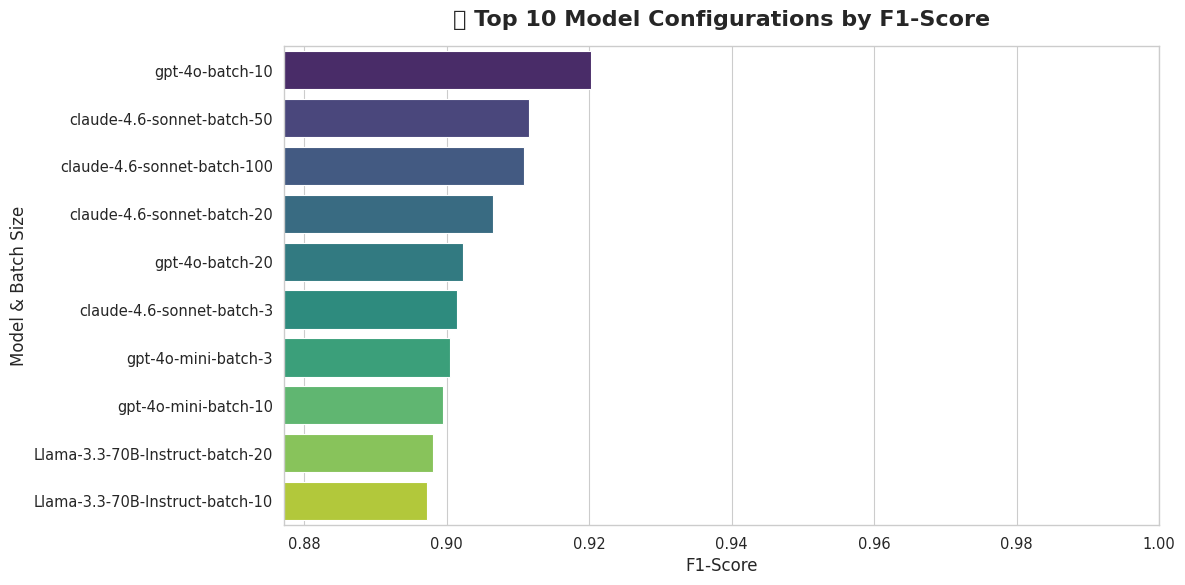

/tmp/ipykernel_4906/2866595478.py:71: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pouya/Documents/Projects/Python/OnlineSentimentAnalysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


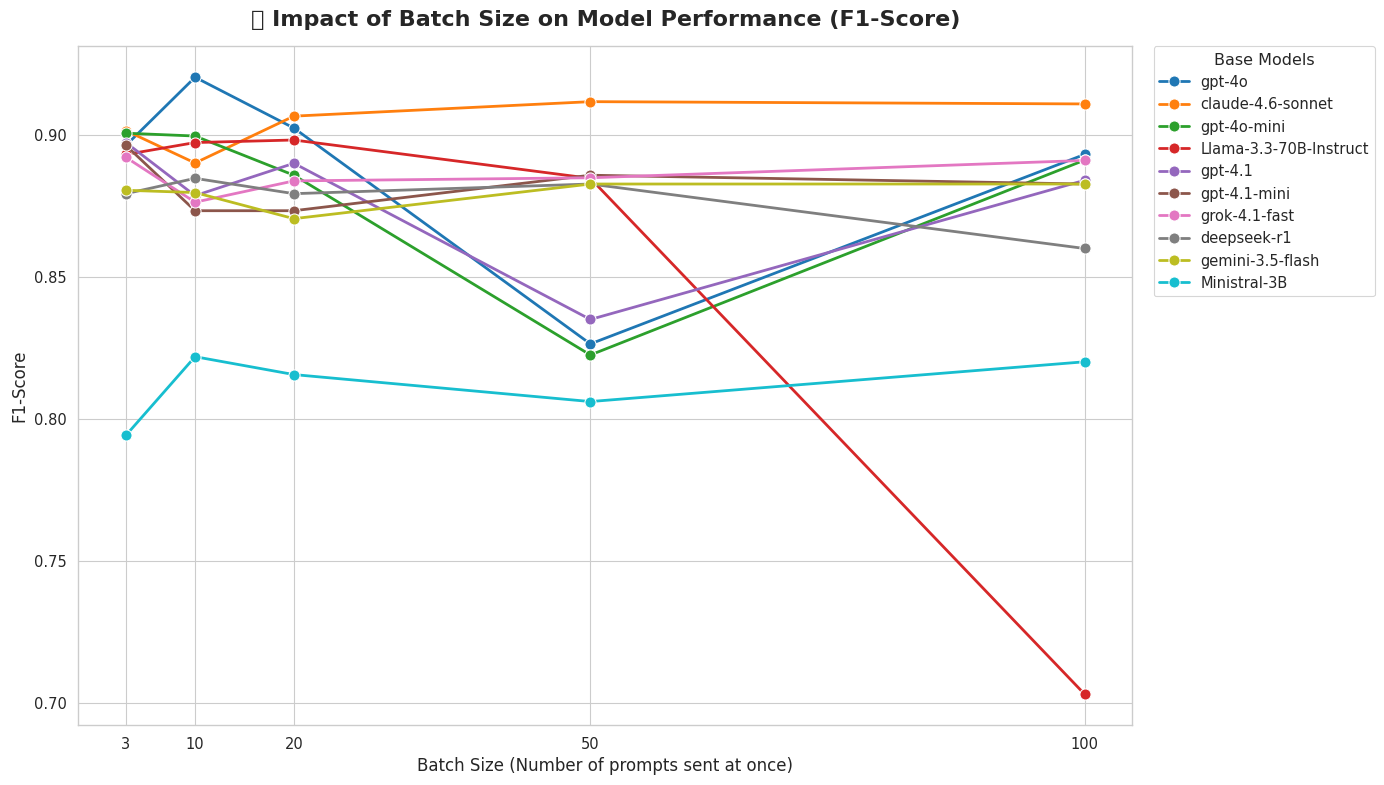

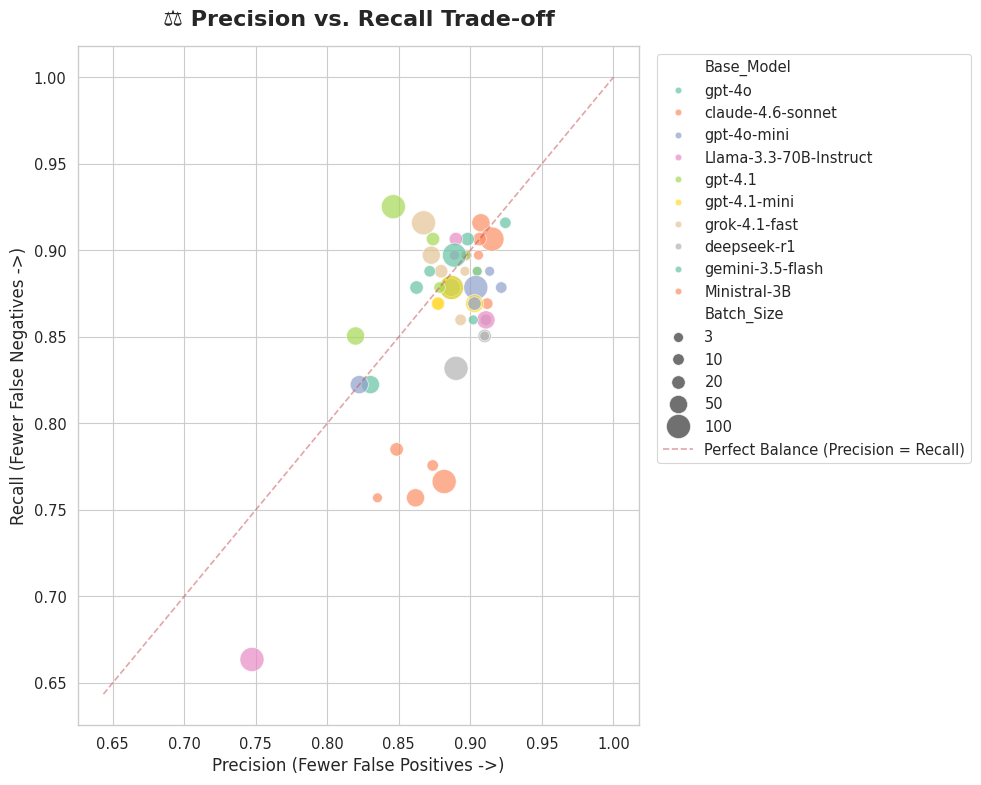

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the evaluation metrics
eval_file = "final_evaluation_metrics.csv"
if not os.path.exists(eval_file):
    print(f"❌ Error: {eval_file} not found. Please run Step 5 first.")
else:
    df_plot = pd.read_csv(eval_file)

    # Preprocessing: Extract Base Model Name and Batch Size from 'Model_File'
    # Example: 'gpt-4o-batch-10' -> Base: 'gpt-4o', Batch: 10
    def extract_features(filename):
        if '-batch-' in filename:
            parts = filename.split('-batch-')
            return parts[0], int(parts[1])
        return filename, 0 # Fallback

    df_plot[['Base_Model', 'Batch_Size']] = pd.DataFrame(
        df_plot['Model_File'].apply(extract_features).tolist(), index=df_plot.index
    )

    # Set seaborn theme for better aesthetics
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # ---------------------------------------------------------
    # Chart 1: Top 10 Configurations by F1-Score
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 6))
    top_10 = df_plot.head(10)
    sns.barplot(data=top_10, x='F1-Score', y='Model_File', hue='Model_File', palette='viridis', legend=False)

    plt.title('🏆 Top 10 Model Configurations by F1-Score', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('F1-Score', fontsize=12)
    plt.ylabel('Model & Batch Size', fontsize=12)

    # Dynamically adjust X-axis to make differences visible
    min_f1 = top_10['F1-Score'].min() - 0.02
    plt.xlim(min_f1, 1.0)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Chart 2: Impact of Batch Size on F1-Score
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 8))

    # Plot lines for each Base_Model
    sns.lineplot(
        data=df_plot,
        x='Batch_Size',
        y='F1-Score',
        hue='Base_Model',
        marker='o',
        markersize=8,
        linewidth=2,
        palette='tab10'
    )

    plt.title('📈 Impact of Batch Size on Model Performance (F1-Score)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Batch Size (Number of prompts sent at once)', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)

    # Set X-ticks exactly to the batch sizes we used
    batch_sizes = sorted(df_plot['Batch_Size'].unique())
    plt.xticks(batch_sizes)

    # Move legend outside the plot
    plt.legend(title='Base Models', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Chart 3: Precision vs. Recall Scatter Plot
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))

    sns.scatterplot(
        data=df_plot,
        x='Precision',
        y='Recall',
        hue='Base_Model',
        size='Batch_Size',
        sizes=(50, 300),
        alpha=0.7,
        palette='Set2'
    )

    # Plot a diagonal line x=y for reference
    min_val = min(df_plot['Precision'].min(), df_plot['Recall'].min()) - 0.02
    plt.plot([min_val, 1], [min_val, 1], 'r--', alpha=0.5, label='Perfect Balance (Precision = Recall)')

    plt.title('⚖️ Precision vs. Recall Trade-off', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Precision (Fewer False Positives ->)', fontsize=12)
    plt.ylabel('Recall (Fewer False Negatives ->)', fontsize=12)

    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()